#**3주차 - 💻 컴퓨터 비전**

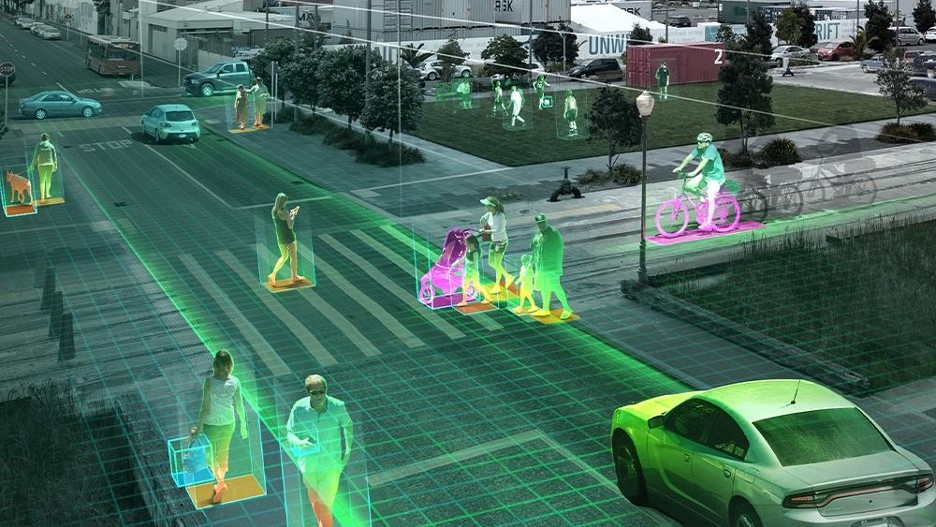

안녕하세요, ToBig's 25기 여러분! 👋
24기 윤정우입니다.

3주차 정규세션 들으시느라 다들 고생하셨습니다.
과제는 컴퓨터 비전의 기초 task인 🖼️ **이미지 분류** 모델 2가지, **ResNet과 ViT (Vision Transformer) 간 비교**로 구성했습니다. 문제를 잘 읽어보시고 과제 수행하시길 바라겠습니다.

### **Q1. 📚 이론 문제(서술형)**

#### **🤔❓ 1-1.** ####
CNN(ResNet)은 이미지 데이터에 대해 강한 귀납적 편향(Inductive Bias)을 가지고 있는 반면, ViT는 이 편향이 매우 낮다고 알려져 있습니다. 여기서 말하는 CNN의 주요 귀납적 편향 2가지(**Locality, Translation Invariance**)가 무엇인지 설명하고, 이러한 차이가 적은 양의 데이터로 학습할 때 두 모델의 성능에 어떤 영향을 미치는지 서술해주세요.

💡 1-1 Locality는 CNN이 작은 영역 단위로 이미지의 특징을 학습하도록 설계되어 있어, 국소적인 패턴을 효과적으로 포착할 수 있다는 것을 의미합니다. Translation Invariance는 동일한 패턴이 이미지 내 어디에 나타나더라도 인식할 수 있도록 해서 위치 변화에 강한 특징 추출을 가능하게 합니다. 이러한 편향 덕분에 CNN은 적은 양의 데이터에서도 안정적으로 학습할 수 있지만, ViT는 이와 같은 편향이 거의 없어 모든 패치의 관계를 직접 학습해야 하므로 데이터가 적을 경우 과적합이 쉽게 발생하고 성능이 낮아질 수 있습니다.

#### **🤔❓ 1-2.**

CNN과 ViT를 쉽게 설명할 때, CNN은 입력 이미지를 국소적(Locally)으로 이해하고, ViT는 전역적(Globally)으로 이해한다고 합니다. 이는 CNN이 kernel를 활용하여 Convolution 연산을 사용하는 반면, ViT는 Self-attention 매커니즘을 사용하는 것과 관계 있습니다.

**ViT의 Self-Attention이 CNN의 Convolution 연산과 비교했을 때, Receptive Field 측면에서 갖는 가장 큰 차이점**이 무엇인지 작성해주세요.


💡 1-2 ViT의 Self-Attention과 CNN의 Convolution 연산을 Receptive Field 관점에서 비교하면, 가장 큰 차이점은 정보를 수용하는 영역의 크기와 범위입니다. CNN은 커널 크기와 층 수에 따라 점진적으로 Receptive Field가 확장되지만, 한 층에서는 국소 영역(Local Region)만을 처리합니다. 반면, ViT의 Self-Attention은 입력 이미지의 모든 패치 간 전역(Global)적인 관계를 한 번에 고려할 수 있어, 초기 단계부터 사실상 전체 이미지에 대한 Receptive Field를 가집니다. 즉, ViT는 CNN보다 훨씬 빠르게 전역 정보를 반영할 수 있습비다.

### **Q2. 👨‍💻 코드 문제 (ResNet-50 vs. ViT)**

#### **2-1. ResNet-50**

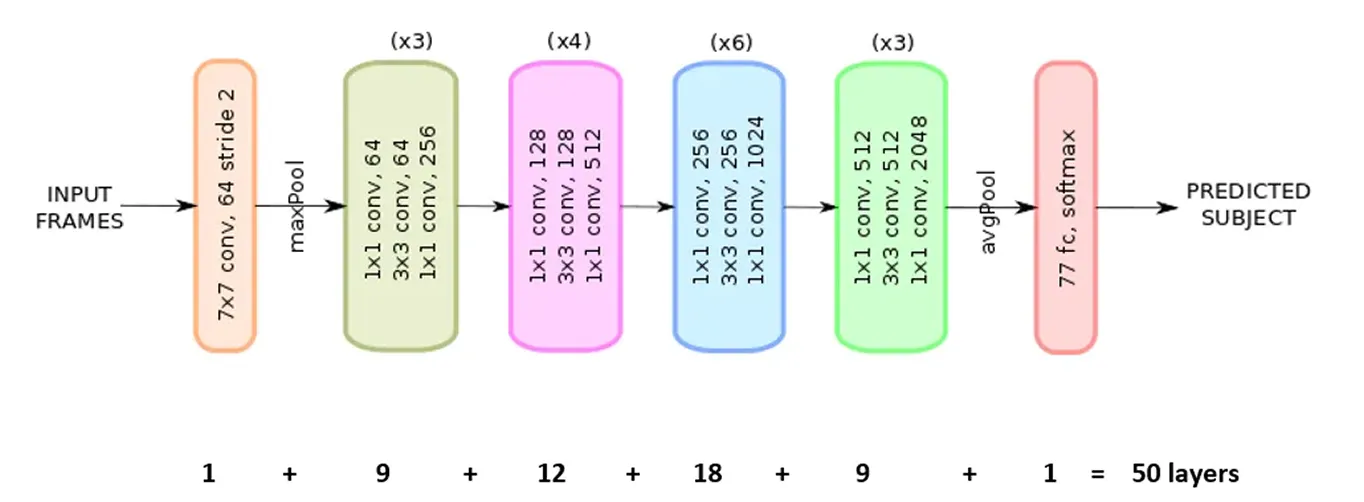

ResNet-50은 2015년 Microsoft에서 제안한 50개 층 구성의 깊은 CNN 모델로, 딥러닝에서 층이 깊어질수록 성능이 저하되는 **기울기 소실 문제를 해결**한 모델입니다.

해당 모델의 핵심은 입력값을 출력값에 직접 더해주는 **잔차 학습 (Residual Learning) 구조인 Skip Connection**에 있습니다. 이를 통해 네트워크는 처음부터 정답을 찾는 대신 입력과 출력의 차이인 '잔차'만을 학습하면 되므로 최적화가 훨씬 쉬워지고, 아주 깊은 층까지 신호 전달이 원활해집니다.

또한, 50층 이상의 ResNet 모델들의 경우, 연산 효율을 극대화하기 위해 **$1 \times 1$ 합성곱**으로 채널을 줄였다가 다시 늘리는 **Bottleneck 구조**를 채택하여, 연산 파라미터 수를 줄이면서도 깊은 층 구조를 구현했습니다.

이후 구현할 ViT 모델 파라미터를 고려하면, ResNet-18이나 ResNet-34과 같은 소규모 모델이 Cifar-10 데이터셋 등의 작은 데이터셋에 적합하나, **Bottle-neck 구조를 직접 구현해보는 경험을 위해 부득이하게 ResNet-50 모델을 선택**한 점은 양해 부탁드리겠습니다. 지금부터는 해당 모델을 **PyTorch로 구현**해보겠습니다.

In [ ]:
### 중요 ###
# Colab 실행 시, 런타임 유형을 GPU (T4, A100 등)로 변경하고 진행하셔야 합니다!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class Conv_block(nn.Module):
    def __init__(self, in_channels, out_channels, activation=True, **kwargs) ->None :
        super(Conv_block, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.activation = activation

    # [TO-DO] Conv Block 구현
    #         위의 init 변수를 고려하여 Conv Block의 forward 함수를 완성해주세요.
    def forward(self, x):
        x = self.conv(x)
        x = self.batchnorm(x)
        if self.activation:
            x = self.relu(x)
        return x

In [ ]:
class Res_block(nn.Module):
    def __init__(self, in_channels, red_channels, out_channels, stride=1, is_plain=False):
        super(Res_block, self).__init__()
        self.is_plain = is_plain
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck 구조: 1x1 (축소) -> 3x3 (특징 추출) -> 1x1 (확장)
        self.convseq = nn.Sequential(
            Conv_block(in_channels, red_channels, kernel_size=1, stride=1, padding=0),
            Conv_block(red_channels, red_channels, kernel_size=3, stride=stride, padding=1),
            Conv_block(red_channels, out_channels, kernel_size=1, stride=1, padding=0, activation=False)
        )

        # Identity Mapping (Skip Connection)
        self.iden = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.iden = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # [TO-DO] Res Block 구현
    #         위의 init 변수를 고려하여 Res Block의 forward 함수를 완성해주세요.
    def forward(self, x):
        identity = x if self.is_plain else self.iden(x)
        out = self.convseq(x)

        # [TO-DO] Skip Connection 구현
        if not self.is_plain:
                out += identity
        out = self.relu(out)

        return out

In [ ]:
class ResNet50(nn.Module):
    def __init__(self, num_classes, is_plain=False):
        super(ResNet50, self).__init__()
        self.num_classes = num_classes
        self.is_plain = is_plain

        # 1. 초기 레이어
        self.conv1 = Conv_block(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 2. ResNet Stages (layers = [3, 4, 6, 3])
        self.layer1 = self._make_layer(64, 64, 256, blocks=3, stride=1)
        self.layer2 = self._make_layer(256, 128, 512, blocks=4, stride=2)
        self.layer3 = self._make_layer(512, 256, 1024, blocks=6, stride=2)
        self.layer4 = self._make_layer(1024, 512, 2048, blocks=3, stride=2)

        # 3. 출력 레이어
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, num_classes)

        # 4. 가중치 초기화
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, red_channels, out_channels, blocks, stride):
        layers = []
        # 스테이지의 첫 번째 블록 (해상도 조절 및 채널 확장 발생)
        layers.append(Res_block(in_channels, red_channels, out_channels, stride, self.is_plain))

        # 나머지 블록들 (채널 유지)
        for _ in range(1, blocks):
            layers.append(Res_block(out_channels, red_channels, out_channels, stride=1, is_plain=self.is_plain))

        return nn.Sequential(*layers)

    # [TO-DO] ResNet50 클래스 구현
    #         위의 init 변수를 고려하여 ResNet50 클래스의 forward 함수를 완성해주세요.
    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

#### **2-2. ViT**

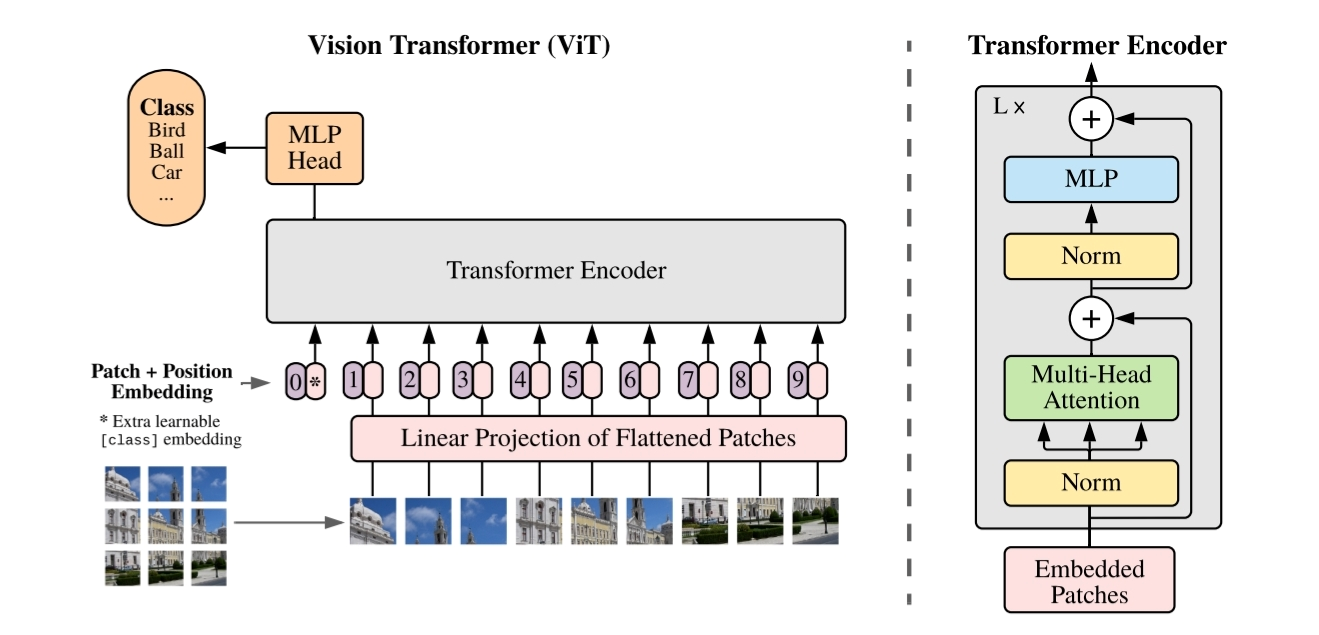

**ViT(Vision Transformer)는** 자연어 처리(NLP) 분야에서 널리 쓰이던 Transformer 구조를 컴퓨터 비전 분야에 적용시킨 모델입니다. 해당 모델은 기존 CNN처럼 필터를 통해 지역적인 특징을 추출하는 대신, **이미지를 격자 형태의 패치(Patch) 단위로 나누어 문장의 단어(Token)처럼 취급**하는 것이 특징입니다.

구조적으로는 먼저 각 이미지를 **고정된 크기의 패치로 분할**한 후, 이를 일렬로 펼쳐 **Linear Projection**을 통해 임베딩 벡터로 변환합니다. 이때 이미지의 공간적 위치 정보를 보존하기 위해 **Positional Embedding**을 적용하며, 분류 작업을 수행하기 위한 특수 토큰인 CLS 토큰을 추가합니다. 이후 **Transformer Encoder 내부에서는 Multi-Head Self-Attention 메커니즘**을 통해 이미지 내 모든 패치 간의 관계를 동시에 파악하는 **Global Receptive Field**을 가집니다.

위와 같은 구조적 특성 덕분에 ViT는 **데이터 규모가 커질수록 뛰어난 확장성(Scalability)을** 보여줍니다. 지금부터는 ViT를 PyTorch로 구현해보겠습니다.

In [ ]:
import math
import torch
import torch.nn as nn
from torchvision import datasets, transforms

In [ ]:
class Encoder(nn.Module) :
    def __init__(self, embed_size=768, num_heads=3, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_size)
        self.attention=nn.MultiheadAttention(embed_size, num_heads, dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_size)
        self.ff = nn.Sequential(
            nn.Linear(embed_size, embed_size * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_size * 4, embed_size),
            nn.Dropout(dropout)
        )

    # [TO-DO] Transformer Encoder 클래스 구현
    #         위의 Encoder 그림과 init 변수를 참고하여 Encoder 클래스의 forward 함수를 완성해주세요.
    def forward(self, x):
        # [TO-DO] Multi-Head Attention 매커니즘 구현
        #         [Hint!] Multi-Head (Self) Attention이므로 Q, K, V 자리에 동일한 입력값이 들어가야 합니다.
        x = self.ln1(attn_out + x)
        x = self.ln2(ff_out + x)
        return x

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, in_channels=3, num_encoders=12, embed_size=768, img_size=(224, 224), patch_size=16, num_classes=10, num_heads=12):
        super().__init__()
        self.patch_size = patch_size

        # 패치 개수 계산
        num_tokens = (img_size[0] // patch_size) * (img_size[1] // patch_size)

        # Patch Embedding: 리니어 프로젝션
        self.patch_embedding = nn.Linear(in_channels * (patch_size ** 2), embed_size)

        # 학습 가능한 파라미터들
        self.class_token = nn.Parameter(torch.randn(1, 1, embed_size))
        self.pos_embedding = nn.Parameter(torch.randn(1, num_tokens + 1, embed_size))

        self.encoders = nn.ModuleList([
            Encoder(embed_size=embed_size, num_heads=num_heads) for _ in range(num_encoders)
        ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_size),
            nn.Linear(embed_size, num_classes)
        )

    # [TO-DO] VisionTransformer 클래스 구현
    #         위의 init 변수를 참고하여 VisionTransformer 클래스의 forward 함수를 완성해주세요.
    def forward(self, x):
        b, c, h, w = x.shape

        # 1. Image to Patches (unfold 사용 방식은 유지하되 뷰 변경)
        # (b, c, h, w) -> (b, num_patches, patch_dim)
        p = self.patch_size
        # [TO-DO] Images to Patches 구현
        #         [Idea Hint!] tensor.unfold을 활용하여 이미지의 가로(dim=3), 세로(dim=2)를 p 크기의 패치로 분할해주세요.
        #         [Code Hint!]
        #          - .unfold(dim, size, step) : 지정한 축(dim)을 따라 size만큼의 창을 step 간격으로 이동시키며 데이터를 추출(분할)하는 메서드
        x = x.unfold(2, p, p).unfold(3, p, p) # (b, c, h/p, w/p, p, p)
        # [TO-DO] Patches to Sequences 구현
        #         [Idea Hint!]
        #          - 1. 패치 내부의 픽셀들을 1차원으로 펼쳐줍니다. (Patch Flattening)
        #          - 2. Transformer는 [Batch, Sequence, Feature] 순서의 텐서를 입력받습니다. 차원의 순서를 바꿔주세요.
        #          - 3. 채널(Color) 정보와 펼쳐진 픽셀 정보를 하나로 통합하여 최종 특징(Feature) 벡터를 만듭니다.
        #         [Code Hint!]
        #          - .view(*shape) : 차원 변경 메서드
        #          - .permute(*dim) : 차원 위치 교환 메서드
        #          - .contiguous() : 비연속적인 텐서 복사 후, 메모리상에 연속적으로 새로 저장하는 메서드
        x = x.contiguous().view(b, c, -1, p*p)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(b, -1, c*p*p)

        # 2. Patch Embedding
        x =  self.patch_embedding(x)

        # 3. Class Token 결합
        class_tokens = self.class_token.expand(b, -1, -1)
        # [TO-DO] Class Token 결합 구현
        #         [Idea Hint!] torch.cat()을 활용하여 class_tokens와 x를 결합해주세요
        #                      이미지 패치 텐서 x = [Batch, Sequence, Embedding]의 3차원 구조로,
        #                      class_token은 이미지 패치 토큰 시퀀스의 맨 앞에 결합되어야 합니다.
        #         [Code Hint!] torch.cat(tensors, dim) : 다수의 텐서를 하나의 축을 기준으로 연결하는 메서드
        x = torch.cat([class_tokens, x], dim=1)

        # 4. Position Embedding 추가
        x = x + self.pos_embedding

        # 5. Transformer Encoders
        for encoder in self.encoders:
            x = encoder(x)

        # 6. MLP Head (Class Token 위치의 출력만 사용)
        x = x[:, 0]
        x = self.mlp_head(x)
        return x

#### **2-3. Performace Comparison on Cifar-10 Dataset**

두 모델 간 이미지 분류 성능 비교 실험을 위한 데이터셋으로 CIFAR-10 데이터셋을 사용합니다. CIFAR-10은 MNIST와 함께 딥러닝 학습의 toy example에 가장 많이 사용되는 데이터셋으로, **10개의 클래스로 구성된 $32 \times 32$크기의 컬러 이미지가 train 50000장, test 10000장 존재**합니다.

In [ ]:
import torch
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
# 하이퍼파라미터 설정
batch_size = 128
epochs = 20
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터 증강 및 정규화
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:05<00:00, 32.8MB/s]


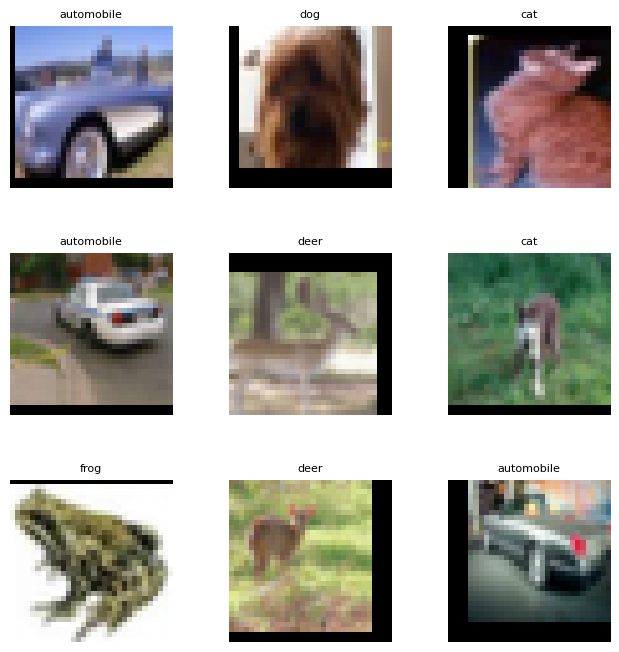

In [ ]:
### Cifar-10 데이터셋 확인 코드 ###
import numpy as np
import matplotlib.pyplot as plt
import torch

# 훈련 데이터 배치 가져오기
labels = trainset.classes

W_grid = 3
L_grid = 3

fig, axes = plt.subplots(L_grid, W_grid, figsize = (8,8))

axes = axes.ravel()

n_train = len(trainset)

# 균일한 간격의 변수들을 생성하여 반복문 실행
for i in np.arange(0, W_grid * L_grid):

    # 0부터 n_train 사이의 랜덤한 인덱스 선택
    index = np.random.randint(0, n_train)
    X_train, y_train = trainloader.dataset[index]

    # [경고 해결] 역정규화 로직 적용
    # Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) 기준 역계산
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

    # 이미지 복원: (X * std) + mean
    X_unnorm = X_train * std + mean
    # imshow를 위해 차원 변경 (C, H, W) -> (H, W, C) 및 값 범위 [0, 1] 제한
    X_unnorm = torch.clamp(X_unnorm.permute(1, 2, 0), 0, 1)

    # 선택된 인덱스의 이미지 표시
    axes[i].imshow(X_unnorm)
    label_index = int(y_train)
    axes[i].set_title(labels[label_index], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

In [ ]:
from torchsummary import summary

# 1. ResNet50 선언 (위에서 작성한 클래스를 그대로 사용하되 num_classes=10 설정)
model_resnet = ResNet50(num_classes=10).to(device)
print("ResNet50 Summary:")
summary(model_resnet, (3, 32, 32))

# 2. ViT 선언 (CIFAR-10 규격: img_size=32, patch_size=4 권장)
model_vit = VisionTransformer(
    img_size=(32, 32),
    patch_size=4,
    embed_size=256,
    num_encoders=6,
    num_heads=8,
    num_classes=10
).to(device)
print("\nViT Summary:")
summary(model_vit, (3, 32, 32))

ResNet50 Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           9,408
       BatchNorm2d-2           [-1, 64, 16, 16]             128
              ReLU-3           [-1, 64, 16, 16]               0
        Conv_block-4           [-1, 64, 16, 16]               0
         MaxPool2d-5             [-1, 64, 8, 8]               0
            Conv2d-6            [-1, 256, 8, 8]          16,384
       BatchNorm2d-7            [-1, 256, 8, 8]             512
            Conv2d-8             [-1, 64, 8, 8]           4,096
       BatchNorm2d-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
       Conv_block-11             [-1, 64, 8, 8]               0
           Conv2d-12             [-1, 64, 8, 8]          36,864
      BatchNorm2d-13             [-1, 64, 8, 8]             128
             ReLU-14 

NameError: name 'attn_out' is not defined

In [ ]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), 100. * correct / total

def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return test_loss / len(test_loader), 100. * correct / total

In [ ]:
# 학습 시간 약 45분 소요 (T4 GPU 기준)
results = {
    "ResNet50": {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []},
    "ViT": {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []}
}

for name, model in [("ResNet50", model_resnet), ("ViT", model_vit)]:
    print(f"\n{'='*20} 🚀 [START] Training: {name} {'='*20}")
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        train_loss, train_acc = train_model(model, trainloader, criterion, optimizer, device)
        test_loss, test_acc = evaluate_model(model, testloader, criterion, device)

        results[name]["train_loss"].append(train_loss)
        results[name]["test_loss"].append(test_loss)
        results[name]["train_acc"].append(train_acc)
        results[name]["test_acc"].append(test_acc)

        print(f"━━━━━━━━━━━━━━ [Epoch {epoch+1:2d}/{epochs}] ━━━━━━━━━━━━━━")
        print(f"  📉 Loss | Train: {train_loss:.4f}  /  Test: {test_loss:.4f}")
        print(f"  🎯 Acc  | Train: {train_acc:6.2f}%  /  Test: {test_acc:6.2f}%")

    print(f"\n{'='*20} ✨ [FINISH] {name} Training {'='*20}\n")


==================== 🚀 [START] Training: ResNet50 ====================
━━━━━━━━━━━━━━ [Epoch  1/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.9184  /  Test: 2.0900
  🎯 Acc  | Train:  32.27%  /  Test:  37.87%
━━━━━━━━━━━━━━ [Epoch  2/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.6851  /  Test: 1.6183
  🎯 Acc  | Train:  40.77%  /  Test:  43.50%
━━━━━━━━━━━━━━ [Epoch  3/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.5834  /  Test: 1.5987
  🎯 Acc  | Train:  44.96%  /  Test:  44.54%
━━━━━━━━━━━━━━ [Epoch  4/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.6914  /  Test: 1.5824
  🎯 Acc  | Train:  41.95%  /  Test:  44.19%
━━━━━━━━━━━━━━ [Epoch  5/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.5108  /  Test: 1.3430
  🎯 Acc  | Train:  46.84%  /  Test:  51.34%
━━━━━━━━━━━━━━ [Epoch  6/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.6082  /  Test: 1.7621
  🎯 Acc  | Train:  45.35%  /  Test:  38.60%
━━━━━━━━━━━━━━ [Epoch  7/20] ━━━━━━━━━━━━━━
  📉 Loss | Train: 1.5911  /  Test: 1.5162
  🎯 Acc  | Train:  44.52%  /  Test:  49.93%
━━━━━━━━━━━━━━ [Ep

### **Q3. 📚 이론 + 👨‍💻 코드 문제(서술형)**

#### **🤔❓ 3.**
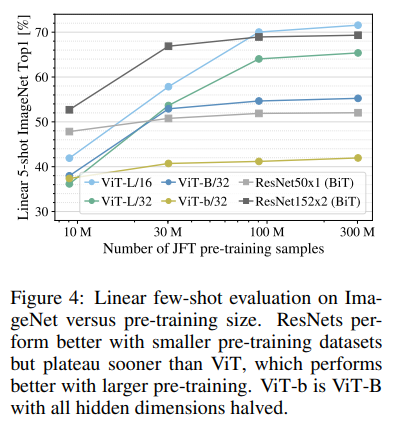

일반적으로 ViT는 CNN보다 이미지 분류 성능이 더 높은 것으로 알려져 있습니다. 이는 위 도표와 같이, ViT 논문에서도 언급되는 바입니다. 그러나 이전까지 진행한 성능 비교 실험에서 **ViT는 ResNet-50 모델보다 Test Accuracy가 약 5-6% 낮은 결과**를 보입니다.

① **왜 이와 같은 결과가 나왔는지** 본인의 의견을 작성해주세요.

② 그렇다면 반대로, pre-training 데이터가 많을 시, 왜 위 도표와 같이, **ViT는 비교적 선형적으로 성능이 상승하는 데 비해, ResNet은 빠르게 성능 향상폭이 줄어드는지 이유**를 작성해주세요.

💡 ViT가 일반적으로 높은 성능을 보인다고 알려져 있지만, 충분히 큰 pretraining 데이터와 적절한 학습이 설정됐을 때 가능합니다. 여기서는 데이터가 적어 ViT의 성능이 낮았던 것으로 보이고, 만약 하이퍼파라미터 세팅이 잘못됐다면 이 부분도 성능에 영향을 미쳤을 것이라고 생각합니다.

CNN 계열 모델인 Resnet은 inductive bias(가중치를 공유하는 것, 지역적 영역 등)을 가지고 있기 때문에 비교적 적은 데이터에서도 이미지의 패턴을 빠르게 학습할 수 있지만 동시에 모델이 학습할 수 있는 표현의 형태를 제한하기도 하기 때문에 데이터가 충분히 많아지더라도 학습으로 인한 성능 향상이 크지 않습니다. 이에 반해, ViT는 이미지를 패치 단위로 나누어 전역 selfattention을 통해 관계를 하급하기 때문에, 초기에는 충분한 구조적 학습이 이루어지지 않아 초반에는 성능이 낮을지라도 데이터가 충분히 많아지면 모델이 복잡한 패턴 등을 충분히 학습할 수 있어 성능이 크게 향상됩니다.

**✨ 수고하셨습니다!**

**👨🏻‍💻 과제 완료 후, 깃허브 제출 부탁드립니다.**